# Notebook 05 — Preprocessing and Augmentation

## What this notebook does
I design and test the preprocessing pipeline: resizing, grayscale-to-RGB conversion, normalisation, and training augmentations. I visualise augmented images to confirm they are medically plausible.

## Why this step matters
Preprocessing must be applied consistently. Mistakes here — such as normalising with test-set statistics — cause data leakage. Augmentations must be conservative for medical images (no vertical flips on CXRs).

## What Python / ML concepts I practise
- Torchvision transforms pipeline
- Visualising augmented images
- Checking normalisation values

## Input files expected
- `data/interim/manifest_clean.csv`

## Output files created
- `reports/figures/augmentation_examples.png`

## How this connects to the main project question
The transform pipeline is the interface between raw images and the model. Getting it right is critical for all subsequent training experiments.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

USE_MOCK_DATA = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms
from src.visualization import set_publication_style, save_figure

cfg   = load_config()
paths = get_paths()
set_publication_style()

manifest = pd.read_csv(paths["interim"] / "manifest_clean.csv")
print(f"Manifest: {manifest.shape}")
print(f"Config image size: {cfg['data']['image_size']}×{cfg['data']['image_size']}")

Manifest: (800, 5)
Config image size: 224×224


## Build Transform Pipelines

I create three separate pipelines: train (with augmentation), val, and test (no augmentation).

**Why no augmentation on val/test?**
Augmentation introduces randomness. If I apply random flips on the test set, different runs would give slightly different metrics, making comparisons unreliable. The test set must be deterministic.

In [2]:
# Build transforms using our helper from src/data_utils.py
# I show each step explicitly so I can understand exactly what happens
# to each image before it reaches the model.

train_transform = build_transforms(
    image_size=cfg["data"]["image_size"],
    split="train",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"],
)

val_transform = build_transforms(
    image_size=cfg["data"]["image_size"],
    split="val",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"],
)

print("Training transform pipeline:")
print(train_transform)
print()
print("Val/Test transform pipeline (no augmentation):")
print(val_transform)

Training transform pipeline:
Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transform pipeline (no augmentation):
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## What each transform step does

| Step | Purpose |
|---|---|
| `Resize(244, 244)` | Resize to slightly larger, then crop to 224 (for augmentation) |
| `RandomCrop(224)` | Crop a random 224×224 patch (simulates different field of view) |
| `RandomHorizontalFlip` | Mirror the image (valid for CXR — lungs are symmetric L/R) |
| `RandomRotation(10°)` | Simulate slight patient rotation during imaging |
| `ColorJitter` | Brightness/contrast variation (simulates different X-ray machine calibration) |
| `ToTensor` | Convert PIL Image (0–255) to PyTorch Tensor (0.0–1.0) |
| `Normalize(mean, std)` | Subtract ImageNet mean, divide by std (required for pretrained ResNet) |

**Important:** No vertical flip — a flipped CXR (heart on wrong side) is not a valid CXR pattern (except in rare situs inversus), and would confuse the model.

Figure saved: 'augmentation_examples.png' and 'augmentation_examples.pdf'


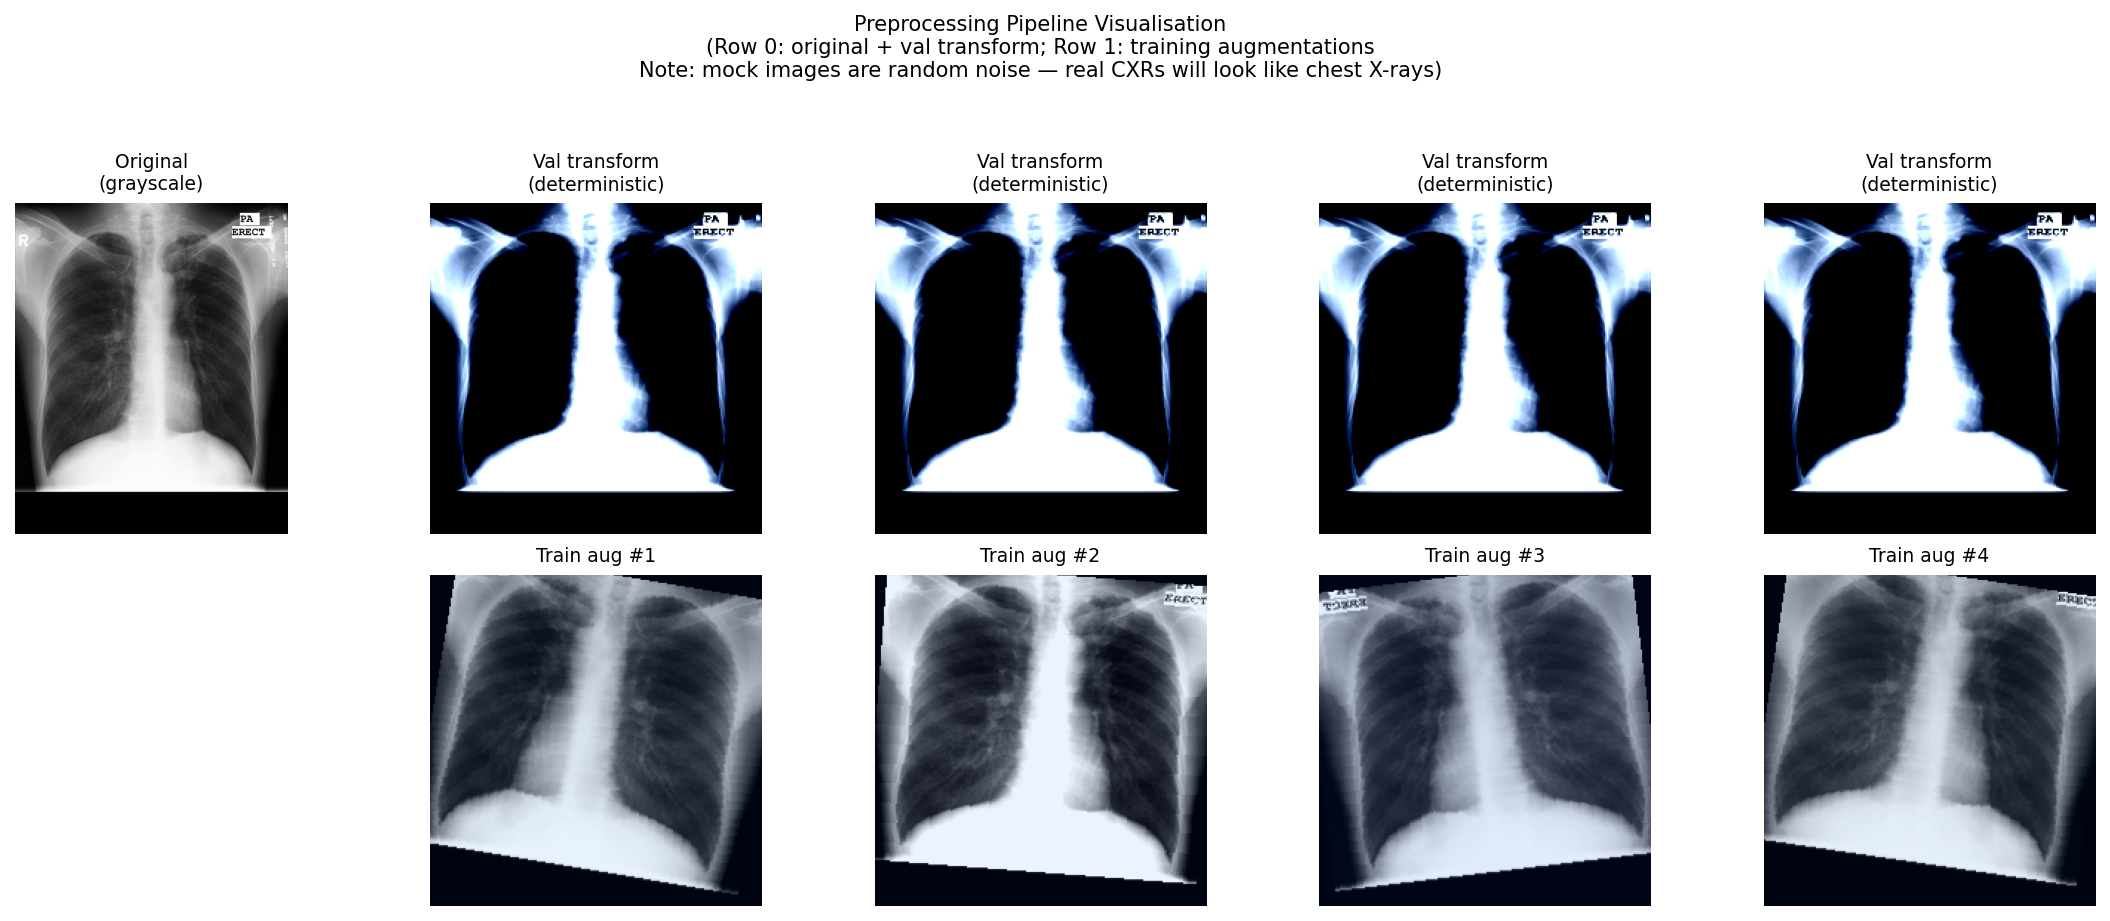

In [3]:
# Visualise augmented images side by side
# I apply the training transform 4 times to the SAME image to show
# the variety of augmentations it can produce.

sample_row = manifest[manifest["label"] == 1].iloc[0]   # TB positive example
sample_path = sample_row["image_path"]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Row 0: original (repeated)
for col in range(5):
    img = Image.open(sample_path).convert("RGB")
    if col == 0:
        axes[0, col].imshow(np.array(Image.open(sample_path).convert("L")), cmap="gray")
        axes[0, col].set_title("Original\n(grayscale)", fontsize=9)
    else:
        # Apply val transform (no aug) and show as tensor
        t = val_transform(img)
        axes[0, col].imshow(t.permute(1,2,0).numpy().clip(0,1))
        axes[0, col].set_title(f"Val transform\n(deterministic)", fontsize=9)
    axes[0, col].axis("off")

# Row 1: training augmentations (random — different each run)
axes[1, 0].set_visible(False)
for col in range(1, 5):
    img = Image.open(sample_path).convert("RGB")
    t = train_transform(img)
    # Clamp to [0,1] for display — normalised tensors can go slightly negative
    t_display = t.permute(1, 2, 0).numpy()
    t_display = (t_display - t_display.min()) / (t_display.max() - t_display.min() + 1e-6)
    axes[1, col].imshow(t_display)
    axes[1, col].set_title(f"Train aug #{col}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle(
    "Preprocessing Pipeline Visualisation\n"
    "(Row 0: original + val transform; Row 1: training augmentations\n"
    "Note: mock images are random noise — real CXRs will look like chest X-rays)",
    fontsize=10, y=1.02
)
plt.tight_layout()
save_figure(fig, "augmentation_examples", paths["figures"], paths["paper_figures"])
plt.show()

## Normalisation Check

In [4]:
# I verify that the normalised tensors have roughly mean≈0, std≈1.
# This is expected for ImageNet-normalised images.

check_tensors = []
for _, row in manifest.sample(n=min(20, len(manifest)), random_state=42).iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    t = val_transform(img)   # Deterministic, no augmentation
    check_tensors.append(t)

stacked = torch.stack(check_tensors)   # Shape: (N, 3, 224, 224)
channel_means = stacked.mean(dim=[0,2,3])
channel_stds  = stacked.std(dim=[0,2,3])

print("After ImageNet normalisation (sample of images):")
print(f"  Channel means (R, G, B): {channel_means.numpy().round(3)}")
print(f"  Channel stds  (R, G, B): {channel_stds.numpy().round(3)}")
print()
print("Expected: means ≈ 0, stds ≈ 1 (approximately)")
print("(Exact values depend on the dataset; mock data will differ from real CXRs)")
print()
print("IMPORTANT: Normalisation statistics are from ImageNet (fixed constants),")
print("NOT computed from our training data. This avoids any leakage.")

After ImageNet normalisation (sample of images):
  Channel means (R, G, B): [0.41  0.549 0.769]
  Channel stds  (R, G, B): [1.223 1.25  1.245]

Expected: means ≈ 0, stds ≈ 1 (approximately)
(Exact values depend on the dataset; mock data will differ from real CXRs)

IMPORTANT: Normalisation statistics are from ImageNet (fixed constants),
NOT computed from our training data. This avoids any leakage.
